In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import KFold, cross_validate, learning_curve
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from lightgbm import LGBMRegressor
import matplotlib.pyplot as plt


In [2]:
#-----------------------------
# CELL 1: Load dataset
# -----------------------------
CLEAN_CSV_PATH = "AirfoilDatset_cleaned_1.csv"  # ensure this file is in same folder as ipynb
df = pd.read_csv(CLEAN_CSV_PATH, low_memory=False)

print("Loaded dataset:", CLEAN_CSV_PATH)
print("Shape:", df.shape)
print("Columns:", list(df.columns))


Loaded dataset: AirfoilDatset_cleaned_1.csv
Shape: (838207, 71)
Columns: ['airfoilName', 'upperSurfaceCoeff1', 'upperSurfaceCoeff2', 'upperSurfaceCoeff3', 'upperSurfaceCoeff4', 'upperSurfaceCoeff5', 'upperSurfaceCoeff6', 'upperSurfaceCoeff7', 'upperSurfaceCoeff8', 'upperSurfaceCoeff9', 'upperSurfaceCoeff10', 'upperSurfaceCoeff11', 'upperSurfaceCoeff12', 'upperSurfaceCoeff13', 'upperSurfaceCoeff14', 'upperSurfaceCoeff15', 'upperSurfaceCoeff16', 'upperSurfaceCoeff17', 'upperSurfaceCoeff18', 'upperSurfaceCoeff19', 'upperSurfaceCoeff20', 'upperSurfaceCoeff21', 'upperSurfaceCoeff22', 'upperSurfaceCoeff23', 'upperSurfaceCoeff24', 'upperSurfaceCoeff25', 'upperSurfaceCoeff26', 'upperSurfaceCoeff27', 'upperSurfaceCoeff28', 'upperSurfaceCoeff29', 'upperSurfaceCoeff30', 'upperSurfaceCoeff31', 'lowerSurfaceCoeff1', 'lowerSurfaceCoeff2', 'lowerSurfaceCoeff3', 'lowerSurfaceCoeff4', 'lowerSurfaceCoeff5', 'lowerSurfaceCoeff6', 'lowerSurfaceCoeff7', 'lowerSurfaceCoeff8', 'lowerSurfaceCoeff9', 'lowerSur

In [4]:
# -----------------------------------------
# CELL 2: Encode airfoilName + feature list
# -----------------------------------------
if "airfoilName" not in df.columns:
    raise ValueError("Column 'airfoilName' not found in dataset!")

le = LabelEncoder()
df["airfoilName_encoded"] = le.fit_transform(df["airfoilName"])

feature_cols = [
    c for c in df.columns
    if c.startswith("upperSurfaceCoeff")
    or c.startswith("lowerSurfaceCoeff")
    or c in ["reynoldsNumber", "alpha", "topXTR", "botXTR", "airfoilName_encoded"]
]

# Targets
target_col_cl = "coefficientLift"
target_col_cd = "coefficientDrag"

for col in [target_col_cl, target_col_cd]:
    if col not in df.columns:
        raise ValueError(f"Target column '{col}' not found in dataset!")

print("No. of features:", len(feature_cols))
print("Feature sample:", feature_cols[:8])
print("Targets:", target_col_cl, "and", target_col_cd)


No. of features: 67
Feature sample: ['upperSurfaceCoeff1', 'upperSurfaceCoeff2', 'upperSurfaceCoeff3', 'upperSurfaceCoeff4', 'upperSurfaceCoeff5', 'upperSurfaceCoeff6', 'upperSurfaceCoeff7', 'upperSurfaceCoeff8']
Targets: coefficientLift and coefficientDrag


In [5]:
# -----------------------------------------
# CELL 3: Clean features to numeric + drop NaN
# -----------------------------------------
# Convert feature columns to numeric safely (handles mixed text)
df[feature_cols] = df[feature_cols].astype(str).apply(lambda col: col.str.strip())
df[feature_cols] = df[feature_cols].apply(pd.to_numeric, errors="coerce")

before = len(df)
df = df.dropna(subset=feature_cols + [target_col_cl, target_col_cd]).reset_index(drop=True)
after = len(df)

print(f"Removed {before - after} rows due to invalid/missing values.")
print("Remaining rows:", after)

X = df[feature_cols].values
y_cl = df[target_col_cl].values
y_cd = df[target_col_cd].values

print("X shape:", X.shape)
print("y_cl shape:", y_cl.shape)
print("y_cd shape:", y_cd.shape)


Removed 1 rows due to invalid/missing values.
Remaining rows: 838206
X shape: (838206, 67)
y_cl shape: (838206,)
y_cd shape: (838206,)


In [6]:
# -----------------------------
# CELL 4: Standardize features
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Scaling done.")


Scaling done.


In [7]:
# ---------------------------------------------------
# CELL 5: Define Base vs Tuned LightGBM (Regression)
# ---------------------------------------------------
# Base LightGBM (initial configuration) — similar to your model comparison config
base_lgbm = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    subsample=0.80,
    colsample_bytree=0.80,
    objective="regression",
    n_jobs=-1,
    random_state=42
)

# Tuned LightGBM (final-style configuration) — similar to your final Cd model
tuned_lgbm = LGBMRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=-1,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_lambda=5,
    min_child_samples=30,
    objective="regression",
    n_jobs=-1,
    random_state=42
)

print("Defined models: base_lgbm, tuned_lgbm")


Defined models: base_lgbm, tuned_lgbm


In [8]:
# --------------------------------------------------------
# CELL 6: CV evaluation helper (MAE, RMSE, R²) mean ± std
# --------------------------------------------------------
def evaluate_regression_cv(model, X, y, cv_splits=3, seed=42):
    """
    Evaluate regression model using KFold CV.
    Returns mean and std for MAE, RMSE, R².
    """
    cv = KFold(n_splits=cv_splits, shuffle=True, random_state=seed)

    scoring = {
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
        "r2": "r2"
    }

    scores = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=-1)

    mae = -scores["test_mae"]
    rmse = -scores["test_rmse"]
    r2 = scores["test_r2"]

    return {
        "MAE_mean": float(mae.mean()),
        "MAE_std": float(mae.std()),
        "RMSE_mean": float(rmse.mean()),
        "RMSE_std": float(rmse.std()),
        "R2_mean": float(r2.mean()),
        "R2_std": float(r2.std()),
    }


def print_metrics(title, m):
    print(title)
    print(f"  MAE  : {m['MAE_mean']:.6f} ± {m['MAE_std']:.6f}")
    print(f"  RMSE : {m['RMSE_mean']:.6f} ± {m['RMSE_std']:.6f}")
    print(f"  R²   : {m['R2_mean']:.4f} ± {m['R2_std']:.4f}")


In [9]:
# ---------------------------------------------------------
# CELL 7 (Brief): Evaluate LightGBM on BOTH targets (Cl, Cd)
# ---------------------------------------------------------
# This is your "proof" evaluation for both targets (so the examiner cannot say you ignored Cl)

base_cl = evaluate_regression_cv(base_lgbm, X_scaled, y_cl, cv_splits=3)
base_cd = evaluate_regression_cv(base_lgbm, X_scaled, y_cd, cv_splits=3)

print_metrics("Base LightGBM (Cl) — 3-fold CV", base_cl)
print_metrics("Base LightGBM (Cd) — 3-fold CV", base_cd)

# Small summary table (optional but recommended in report)
both_targets_table = pd.DataFrame([
    {"Target": "Cl (coefficientLift)", "MAE": base_cl["MAE_mean"], "RMSE": base_cl["RMSE_mean"], "R²": base_cl["R2_mean"]},
    {"Target": "Cd (coefficientDrag)", "MAE": base_cd["MAE_mean"], "RMSE": base_cd["RMSE_mean"], "R²": base_cd["R2_mean"]},
])

both_targets_table_rounded = both_targets_table.copy()
both_targets_table_rounded["MAE"] = both_targets_table_rounded["MAE"].map(lambda v: f"{v:.6f}")
both_targets_table_rounded["RMSE"] = both_targets_table_rounded["RMSE"].map(lambda v: f"{v:.6f}")
both_targets_table_rounded["R²"] = both_targets_table_rounded["R²"].map(lambda v: f"{v:.4f}")

both_targets_table_rounded


Base LightGBM (Cl) — 3-fold CV
  MAE  : 0.083758 ± 0.000125
  RMSE : 0.112972 ± 0.000287
  R²   : 0.9767 ± 0.0001
Base LightGBM (Cd) — 3-fold CV
  MAE  : 0.006699 ± 0.000004
  RMSE : 0.010228 ± 0.000018
  R²   : 0.8576 ± 0.0004


,Target,MAE,RMSE,R²
0,Cl (coefficientLift),0.083758,0.112972,0.9767
1,Cd (coefficientDrag),0.006699,0.010228,0.8576


In [10]:
# -------------------------------------------------------------------
# CELL 8 (MAIN): Base vs Tuned LightGBM comparison for Cd (detailed)
# -------------------------------------------------------------------
# This matches your report focus: 5.2.4.1 Base, 5.2.4.2 Tuned, 5.2.4.3 Improvement

base_cd_metrics = evaluate_regression_cv(base_lgbm, X_scaled, y_cd, cv_splits=3)
tuned_cd_metrics = evaluate_regression_cv(tuned_lgbm, X_scaled, y_cd, cv_splits=3)

print_metrics("Base LightGBM (Cd) — 3-fold CV", base_cd_metrics)
print_metrics("Tuned LightGBM (Cd) — 3-fold CV", tuned_cd_metrics)


Base LightGBM (Cd) — 3-fold CV
  MAE  : 0.006699 ± 0.000004
  RMSE : 0.010228 ± 0.000018
  R²   : 0.8576 ± 0.0004
Tuned LightGBM (Cd) — 3-fold CV
  MAE  : 0.006172 ± 0.000014
  RMSE : 0.009444 ± 0.000027
  R²   : 0.8786 ± 0.0005


In [11]:
# -----------------------------------------
# CELL 9: Report-ready comparison table (Cd)
# -----------------------------------------
comparison_table = pd.DataFrame([
    {
        "Model Type": "LightGBM (Base Model)",
        "MAE": base_cd_metrics["MAE_mean"],
        "RMSE": base_cd_metrics["RMSE_mean"],
        "R²": base_cd_metrics["R2_mean"]
    },
    {
        "Model Type": "LightGBM (Tuned Model)",
        "MAE": tuned_cd_metrics["MAE_mean"],
        "RMSE": tuned_cd_metrics["RMSE_mean"],
        "R²": tuned_cd_metrics["R2_mean"]
    }
])

comparison_table_report = comparison_table.copy()
comparison_table_report["MAE"] = comparison_table_report["MAE"].map(lambda v: f"{v:.6f}")
comparison_table_report["RMSE"] = comparison_table_report["RMSE"].map(lambda v: f"{v:.6f}")
comparison_table_report["R²"] = comparison_table_report["R²"].map(lambda v: f"{v:.4f}")

comparison_table_report


,Model Type,MAE,RMSE,R²
0,LightGBM (Base Model),0.006699,0.010228,0.8576
1,LightGBM (Tuned Model),0.006172,0.009444,0.8786


In [12]:
# -----------------------------------------------------------
# CELL 10: (Optional) Train tuned model on FULL data (Cd only)
# -----------------------------------------------------------
# This is optional, but it helps you show "final trained model" metrics (like senior sample outputs)

tuned_lgbm.fit(X_scaled, y_cd)
y_pred_train = tuned_lgbm.predict(X_scaled)

mae_train = mean_absolute_error(y_cd, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_cd, y_pred_train))
r2_train = r2_score(y_cd, y_pred_train)

print("Tuned LightGBM (Cd) — trained on FULL dataset")
print(f"  MAE  : {mae_train:.6f}")
print(f"  RMSE : {rmse_train:.6f}")
print(f"  R²   : {r2_train:.4f}")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011730 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 16737
[LightGBM] [Info] Number of data points in the train set: 838206, number of used features: 67
[LightGBM] [Info] Start training from score 0.035051


c:\Users\peeye\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Tuned LightGBM (Cd) — trained on FULL dataset
  MAE  : 0.006092
  RMSE : 0.009309
  R²   : 0.8820


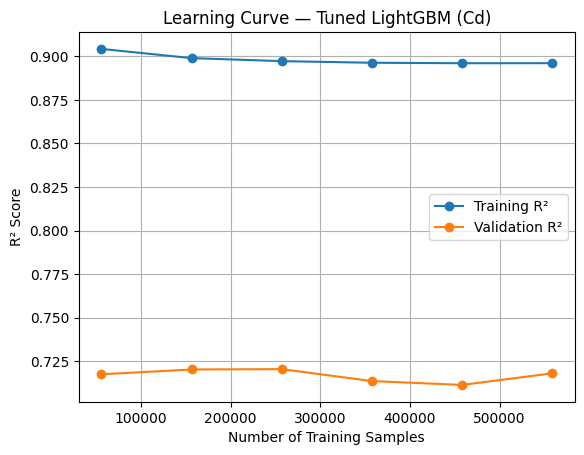

In [13]:
# ------------------------------------------------------------
# CELL 11: (Optional) Learning curve for tuned LightGBM (Cd)
# ------------------------------------------------------------
# This is the closest equivalent to the senior sample "learning curve" style.
# If this takes long, reduce the number of train_sizes points.

train_sizes, train_scores, val_scores = learning_curve(
    estimator=tuned_lgbm,
    X=X_scaled,
    y=y_cd,
    train_sizes=np.linspace(0.1, 1.0, 6),
    cv=3,
    scoring="r2",
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure()
plt.plot(train_sizes, train_mean, marker="o", label="Training R²")
plt.plot(train_sizes, val_mean, marker="o", label="Validation R²")
plt.xlabel("Number of Training Samples")
plt.ylabel("R² Score")
plt.title("Learning Curve — Tuned LightGBM (Cd)")
plt.legend()
plt.grid(True)
plt.show()


In [14]:
# ------------------------------------------------------------
# CELL 12: (Optional) Improvement % calculation (for discussion)
# ------------------------------------------------------------
rmse_improve_pct = (base_cd_metrics["RMSE_mean"] - tuned_cd_metrics["RMSE_mean"]) / base_cd_metrics["RMSE_mean"] * 100
mae_improve_pct = (base_cd_metrics["MAE_mean"] - tuned_cd_metrics["MAE_mean"]) / base_cd_metrics["MAE_mean"] * 100
r2_improve = tuned_cd_metrics["R2_mean"] - base_cd_metrics["R2_mean"]

print(f"RMSE improvement: {rmse_improve_pct:.2f}%")
print(f"MAE improvement : {mae_improve_pct:.2f}%")
print(f"R² improvement  : {r2_improve:.4f} (absolute increase)")


RMSE improvement: 7.66%
MAE improvement : 7.87%
R² improvement  : 0.0210 (absolute increase)
